# 01b: Periodic Seam Blending

Explores a single-chart approach to suppressing seam artefacts in UV projections.

The NuVo parameterization places a seam somewhere in UV space (typically near u = 0/1).
Points near the seam suffer from larger distortions because the network must "cut" the surface there.
The idea: generate a second projection with the seam shifted by half a period (u → (u + 0.5) mod 1),
then blend the two using distance-to-seam weights so that every pixel is dominated by whichever
map has its seam furthest away.

In [10]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

from seamless import Parameterizer

## Load a synthetic volume

The synthetic file stores a 4D microscopy mock-up `(T, Z, Y, X)`. The `topology` attribute names the geometry; ellipsoids are closed surfaces, so we map them to the `'cylinder'` Nuvo topology.

In [11]:
seg_file = Path('data/synthetic/ellipsoid.h5')

with h5py.File(seg_file, 'r') as f:
    volumes = f['microscopy_mockup'][:]            # (T, Z, Y, X)
    file_topology = f.attrs.get('topology', 'ellipsoid')

# Map the geometry name to a Nuvo topology string.
NUVO_TOPOLOGY = {'ellipsoid': 'cylinder', 'cylinder': 'cylinder', 'bent_sheet': 'bent_sheet'}
topology = NUVO_TOPOLOGY.get(file_topology, 'cylinder')

print(f'Volumes: {volumes.shape}  (T, Z, Y, X)')
print(f'File topology: {file_topology}  ->  Nuvo topology: {topology}')

Volumes: (2, 256, 256, 256)  (T, Z, Y, X)
File topology: ellipsoid  ->  Nuvo topology: cylinder


## Build a `Parameterizer` from the first frame

`Parameterizer.from_volume` runs the surface-extraction stage for you: binarize at `threshold` → keep the largest connected component → marching cubes → random subsample. The point cloud is normalized internally and surface normals are estimated automatically.

In [12]:
t0 = 0
param = Parameterizer.from_volume(
    volumes[t0],
    topology=topology,
    threshold=43,             # synthetic mock-up: background < 43 < interior
    num_target_points=20_000,
    num_charts = 2,
)

print(f'Surface points: {param.xyz.shape[0]}')
print(f'Device: {param.device}')

Surface points: 20000
Device: mps


## Train the NuvoMLP (t = 0)

Full training on the first frame. Iteration counts come from `ParameterizationConfig` (default 300 at t=0); pass `iterations=` to override. This takes a couple of minutes on CPU/MPS.

In [13]:
model = param.train(iterations=1000, verbose=True, lr=1e-3, use_warm_start=False)
# use_warm_start=True would run the analytical-UV Phase A first;
# for multi-chart it uses a fixed left/right split which can bias chart assignment.

uv_map = param.get_uv_map()              # (N, 2) UV coordinates, tiled: chart k → u ∈ [k, k+1]
print(f'UV map: {uv_map.shape}')
print(f'u in [{uv_map[:, 0].min():.2f}, {uv_map[:, 0].max():.2f}]',
      f'v in [{uv_map[:, 1].min():.2f}, {uv_map[:, 1].max():.2f}]')

────────────────── Phase 5 – Nuvo Parameterisation ───────────────────
  num_charts=2  topology=cylinder  pe_degree=2
  curriculum: Phase B (geometry) → Phase C (full Nuvo)

  [warm-start] Skipped (use_warm_start=False).

 iter  phase     total     conf    strch    clust     surf      323      232       σ
──────────────────────────────────────────────────────────────────────
  100      C    1.1587   0.4581   0.5994   1.7180   0.0093   0.1011   0.0342  0.8975
  200      C    1.1587   0.4489   0.5049   1.7178   0.0075   0.0489   0.0161  0.7983
  300      C    1.1608   0.4480   0.4230   1.7176   0.0068   0.0310   0.0083  0.7060
  400      C    1.1552   0.4398   0.3323   1.7180   0.0058   0.0219   0.0071  0.6204
  500      C    1.1225   0.4227   0.2396   1.7183   0.0051   0.0160   0.0037  0.5412
  600      C    1.1037   0.3995   0.1700   1.7178   0.0051   0.0137   0.0033  0.4685
  700      C    1.0756   0.3618   0.1229   1.7178   0.0045   0.0115   0.0030  0.4025
  800      C    1.0640   0.

## Visualize the learned UV map

Each 3D surface point now has a 2D `(u, v)` coordinate. Coloring by depth (Z) shows how the surface is unrolled onto the unit square.

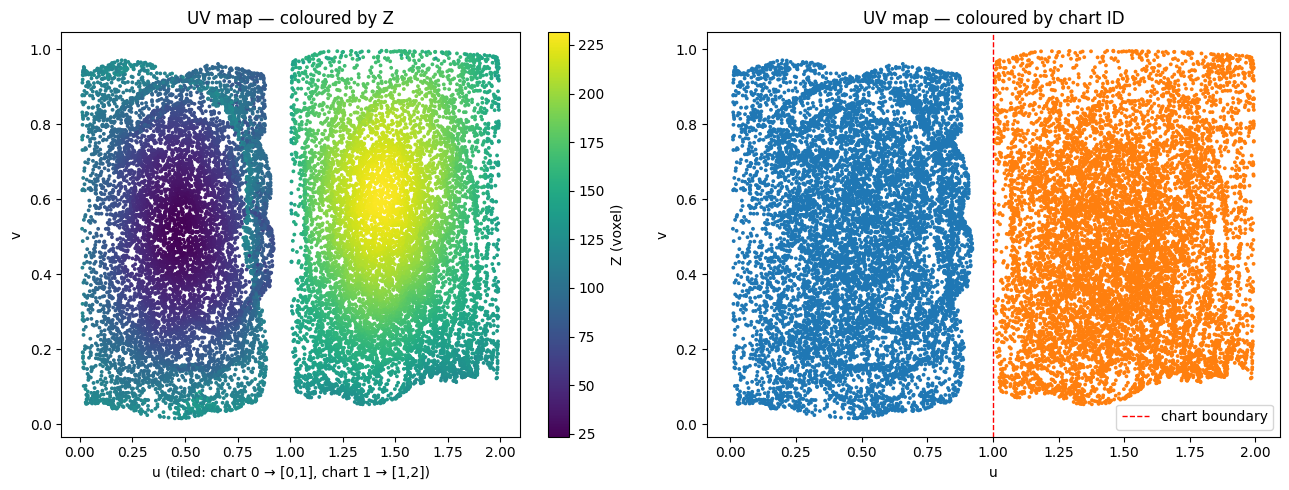

In [14]:
pts = param.points_voxel.numpy()   # surface points in voxel space
chart_ids = param.chart_ids        # (N,) int — 0 or 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(uv_map[:, 0], uv_map[:, 1], c=pts[:, 0], s=3, cmap='viridis')
axes[0].set(xlabel='u (tiled: chart 0 → [0,1], chart 1 → [1,2])', ylabel='v',
            title='UV map — coloured by Z')
fig.colorbar(sc, ax=axes[0], label='Z (voxel)')

axes[1].scatter(uv_map[:, 0], uv_map[:, 1], c=chart_ids, s=3, cmap='tab10', vmin=0, vmax=9)
axes[1].axvline(1.0, color='red', linewidth=1, linestyle='--', label='chart boundary')
axes[1].set(xlabel='u', ylabel='v', title='UV map — coloured by chart ID')
axes[1].legend()

plt.tight_layout()
plt.show()

## Project the volume onto UV space

`project_to_uv_along_normals` samples the volume along the surface normal at several offsets, producing a multi-layer image stack. The max-projection across layers is a clean 2D cartographic view of the surface.

Number of charts: 2
Per-chart stack shape: (6, 512, 512)  (layers, H, W)


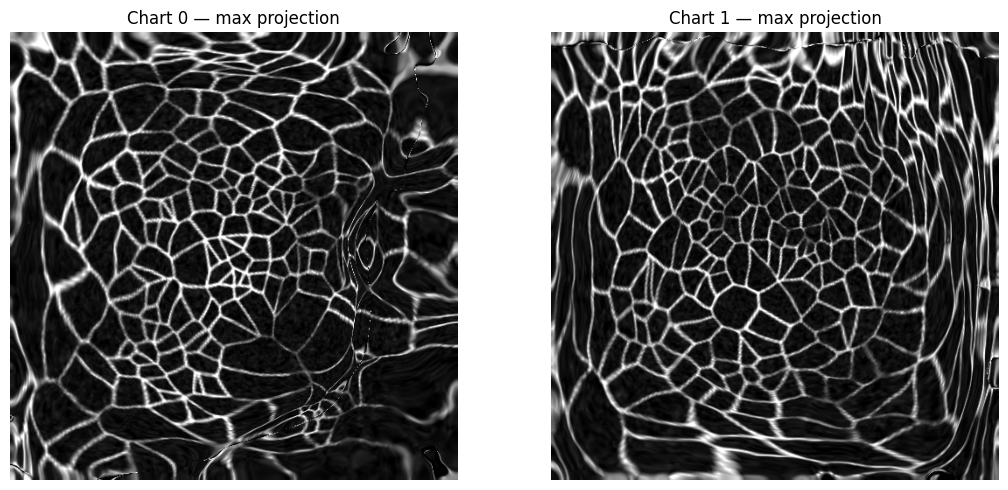

In [15]:
# With num_charts=2, project_to_uv_along_normals returns a list of K arrays.
multilayers = param.project_to_uv_along_normals(volumes[t0], uv_res=512)

max_proj_0 = multilayers[0].max(axis=0)   # chart 0  — (H, W)
max_proj_1 = multilayers[1].max(axis=0)   # chart 1  — (H, W)
max_projection = max_proj_0               # kept for downstream cells

print(f'Number of charts: {len(multilayers)}')
print(f'Per-chart stack shape: {multilayers[0].shape}  (layers, H, W)')

kw = dict(cmap='gray',
          vmin=np.nanpercentile(np.concatenate([max_proj_0.ravel(), max_proj_1.ravel()]), 1),
          vmax=np.nanpercentile(np.concatenate([max_proj_0.ravel(), max_proj_1.ravel()]), 99))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(max_proj_0, **kw)
axes[0].set_title('Chart 0 — max projection')
axes[1].imshow(max_proj_1, **kw)
axes[1].set_title('Chart 1 — max projection')
for a in axes:
    a.axis('off')
plt.tight_layout()
plt.show()

## Convex hull masking

By default the projection samples the full 512×512 UV grid, including pixels that fall
outside the actual UV support of the surface. The NuVo inverse model extrapolates there,
effectively stretching the surface to fill the square.

Passing `use_hull_mask=True` fits a Delaunay triangulation to the training UV point cloud
and sets pixels outside that support to `NaN`, removing the border artefacts.

/var/folders/1r/lj0gk2xn5b349bf26j9t4whw0000gs/T/ipykernel_57500/1625726148.py:7: RuntimeWarning: All-NaN slice encountered
  max_masked_0 = np.nanmax(multilayers_masked[0], axis=0)
/var/folders/1r/lj0gk2xn5b349bf26j9t4whw0000gs/T/ipykernel_57500/1625726148.py:8: RuntimeWarning: All-NaN slice encountered
  max_masked_1 = np.nanmax(multilayers_masked[1], axis=0)


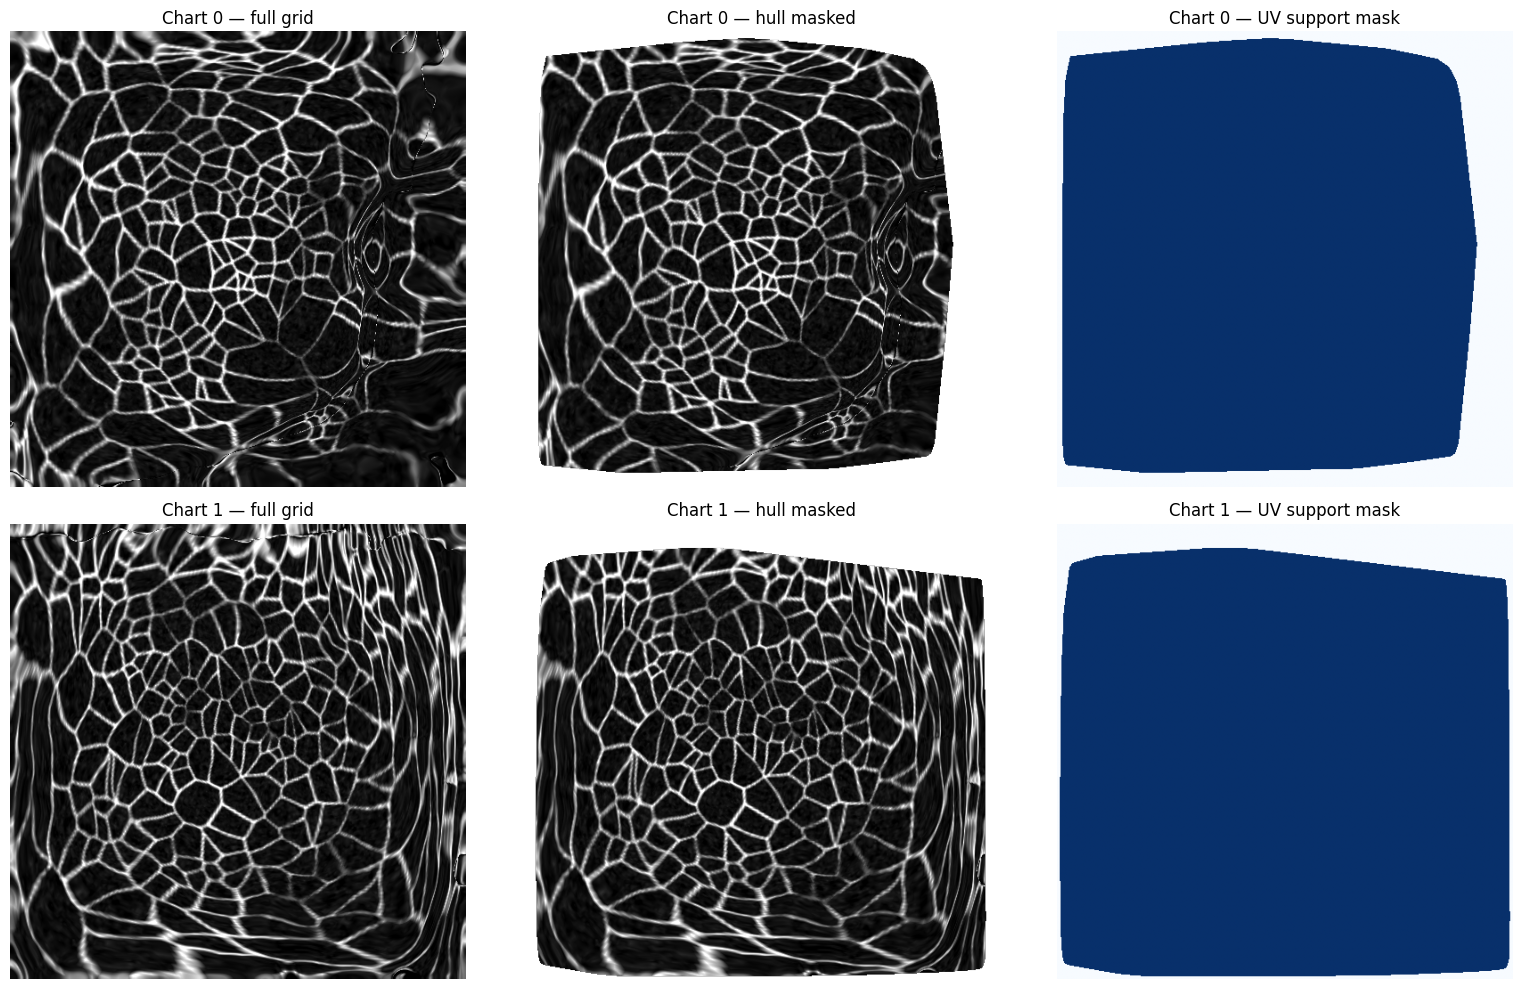

Chart 0: 18.3% pixels outside UV support
Chart 1: 10.7% pixels outside UV support


In [16]:
from seamless.core.geometry import uv_convex_hull_mask

# With num_charts=2, use_hull_mask=True computes a per-chart mask automatically.
multilayers_masked = param.project_to_uv_along_normals(
    volumes[t0], uv_res=512, use_hull_mask=True,
)
max_masked_0 = np.nanmax(multilayers_masked[0], axis=0)
max_masked_1 = np.nanmax(multilayers_masked[1], axis=0)

# Build per-chart hull masks for visualisation.
# uv_map is tiled: chart k has u in [k, k+1] → shift back to [0, 1].
uv_chart0 = uv_map[chart_ids == 0].copy(); uv_chart0[:, 0] -= 0
uv_chart1 = uv_map[chart_ids == 1].copy(); uv_chart1[:, 0] -= 1
hull_mask_0 = uv_convex_hull_mask(uv_chart0, 512)
hull_mask_1 = uv_convex_hull_mask(uv_chart1, 512)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
kw = dict(cmap='gray',
          vmin=np.nanpercentile(np.concatenate([max_proj_0.ravel(), max_proj_1.ravel()]), 1),
          vmax=np.nanpercentile(np.concatenate([max_proj_0.ravel(), max_proj_1.ravel()]), 99))

axes[0, 0].imshow(max_proj_0,    **kw);  axes[0, 0].set_title('Chart 0 — full grid')
axes[0, 1].imshow(max_masked_0,  **kw);  axes[0, 1].set_title('Chart 0 — hull masked')
axes[0, 2].imshow(hull_mask_0, cmap='Blues'); axes[0, 2].set_title('Chart 0 — UV support mask')

axes[1, 0].imshow(max_proj_1,    **kw);  axes[1, 0].set_title('Chart 1 — full grid')
axes[1, 1].imshow(max_masked_1,  **kw);  axes[1, 1].set_title('Chart 1 — hull masked')
axes[1, 2].imshow(hull_mask_1, cmap='Blues'); axes[1, 2].set_title('Chart 1 — UV support mask')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

for k, mask in enumerate([hull_mask_0, hull_mask_1]):
    print(f'Chart {k}: {(~mask).mean()*100:.1f}% pixels outside UV support')

## Time-series warm-start

For a sequence, reuse the trained network as the starting point for the next frame — full training at `t = 0`, then a short fine-tune for each subsequent frame via `base_model=`. This is the core trick of the legacy timeseries script and is far faster than training every frame from scratch.

t=1: projection (512, 512)


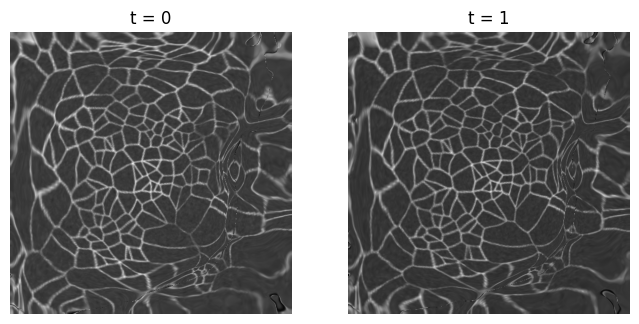

In [17]:
n_frames = min(12, volumes.shape[0])
projections = [max_projection]
base = model

for t in range(1, n_frames):
    p_t = Parameterizer.from_volume(volumes[t], topology=topology,
                                    threshold=43, num_target_points=20_000)
    p_t.train(base_model=base)           # fine-tune from the previous frame (50 iters)
    base = p_t.get_model()
    proj = p_t.project_to_uv_along_normals(volumes[t], uv_res=512).max(axis=0)
    projections.append(proj)
    print(f't={t}: projection {proj.shape}')

fig, axes = plt.subplots(1, len(projections), figsize=(4 * len(projections), 4))
for t, (ax, proj) in enumerate(zip(np.atleast_1d(axes), projections)):
    ax.imshow(proj, cmap='gray')
    ax.set_title(f't = {t}')
    ax.axis('off')
plt.show()

## Persist the projection to HDF5

Save the trained map + projection to a `_uv_projection.h5` file (the schema the flow
methods consume), then reload it to confirm the round-trip.

In [18]:
from seamless import ProjectedFrame, save_projection_h5, FlowEstimator
from pathlib import Path

Path('outputs').mkdir(exist_ok=True)
frame0 = ProjectedFrame.from_parameterizer(param, volumes[t0], t=t0, uv_res=512)

# Multi-chart: charts are tiled along W → shape is (L, H, K*W)
print(f'multilayer shape: {frame0.multilayer.shape}  (layers, H, K×W)')
print(f'max_projection shape: {frame0.max_projection.shape}')

save_projection_h5('outputs/ellipsoid_projection.h5', [frame0], topology=topology)
print('saved outputs/ellipsoid_projection.h5')

multilayer shape: (6, 512, 1024)  (layers, H, K×W)
max_projection shape: (512, 1024)
saved outputs/ellipsoid_projection.h5


## Summary

With the high-level API the whole per-frame workflow is just:

```python
param = Parameterizer.from_volume(volume, topology='cylinder')
param.train()                                 # or train(base_model=prev) to warm-start
uv_map = param.get_uv_map()
multilayer = param.project_to_uv_along_normals(volume)
max_projection = multilayer.max(axis=0)
```

The `Parameterizer` handles surface extraction, normalization, normal estimation, NuvoMLP training, and volumetric projection — replacing ~100 lines of the original `nuvo_projection_timeseries.py`.

---
## Periodic seam blending (single chart, no retraining)

### Strategy

1. **Original map** — query the inverse NuVo on the regular grid `u ∈ [0, 1]`. Seam falls at the left/right edges.
2. **Shifted map** — query on `u' = (u + 0.5) mod 1`. The seam is now at `u = 0.5`, i.e. the centre column of the image. Spatially roll the result by `−uv_res//2` columns to re-align it with the original layout.
3. **Distance-to-seam weights** — for column index `c`:
   - `w_orig[c]  = min(c, N−1−c)` — zero at the left/right edges, maximum at the centre
   - `w_shift[c] = |c − (N−1)/2|` — zero at the centre, maximum at the edges
   - These two are complementary and sum to the constant `(N−1)/2`, so blending is a true weighted average.
4. **Blend** — `proj_blend = (w_orig · proj_orig + w_shift · proj_shift_aligned) / (w_orig + w_shift)`

The result should show no discontinuity at either edge or centre.

In [19]:
from seamless.cartography.projection import project_surface

# Seam blending demonstrated on chart 0 (chart_idx=0).
# Chart 1 can be treated identically — its seam is independent.
uv_res     = 512
vol        = np.ascontiguousarray(volumes[t0], dtype=np.float32)
norm_pts   = param.xyz.detach().cpu().numpy()
pts_voxel  = param.points_voxel.detach().cpu().numpy()
offsets    = np.linspace(-5.0, 5.0, 6)
CHART      = 0   # change to 1 to apply the same analysis to the other chart

lin = np.linspace(0.0, 1.0, uv_res, dtype=np.float32)
uu, vv = np.meshgrid(lin, lin, indexing='xy')   # (H, W) each

# ── 1. Original projection (seam at u = 0/1  →  left & right edges) ──────────
uv_flat_orig = np.stack([uu.ravel(), vv.ravel()], axis=1)

layers_orig, _, _ = project_surface(
    map_model=param.model, uv_flat=uv_flat_orig, vol=vol,
    norm_points=norm_pts, points=pts_voxel, topology=param.topology,
    device=param.device, uv_res=uv_res, normal_offsets=offsets, chart_idx=CHART,
)
proj_orig = np.nanmax(np.stack(layers_orig), axis=0)   # (H, W)

# ── 2. Shifted projection (seam moved to u = 0.5  →  centre column) ──────────
uu_shift = (uu + 0.5) % 1.0
uv_flat_shift = np.stack([uu_shift.ravel(), vv.ravel()], axis=1)

layers_shift, _, _ = project_surface(
    map_model=param.model, uv_flat=uv_flat_shift, vol=vol,
    norm_points=norm_pts, points=pts_voxel, topology=param.topology,
    device=param.device, uv_res=uv_res, normal_offsets=offsets, chart_idx=CHART,
)
proj_shift = np.nanmax(np.stack(layers_shift), axis=0)   # seam at centre column

# Re-align: roll left by uv_res//2 so pixel (r,c) → surface at u = c/(uv_res-1)
proj_shift_aligned = np.roll(proj_shift, -uv_res // 2, axis=1)

# ── 3. Distance-to-seam weights ───────────────────────────────────────────────
c = np.arange(uv_res, dtype=float)
w_orig  = np.minimum(c, uv_res - 1 - c)
w_shift = np.abs(c - (uv_res - 1) / 2.0)

w_o = w_orig[np.newaxis, :]
w_s = w_shift[np.newaxis, :]
w_t = w_o + w_s

# ── 4. Blend ──────────────────────────────────────────────────────────────────
proj_blend = (w_o * proj_orig + w_s * proj_shift_aligned) / w_t

print(f'Chart {CHART} — seam blend computed.')
print(f'  w_total (should be constant): min={w_t.min():.1f}  max={w_t.max():.1f}')

Chart 0 — seam blend computed.
  w_total (should be constant): min=255.5  max=255.5


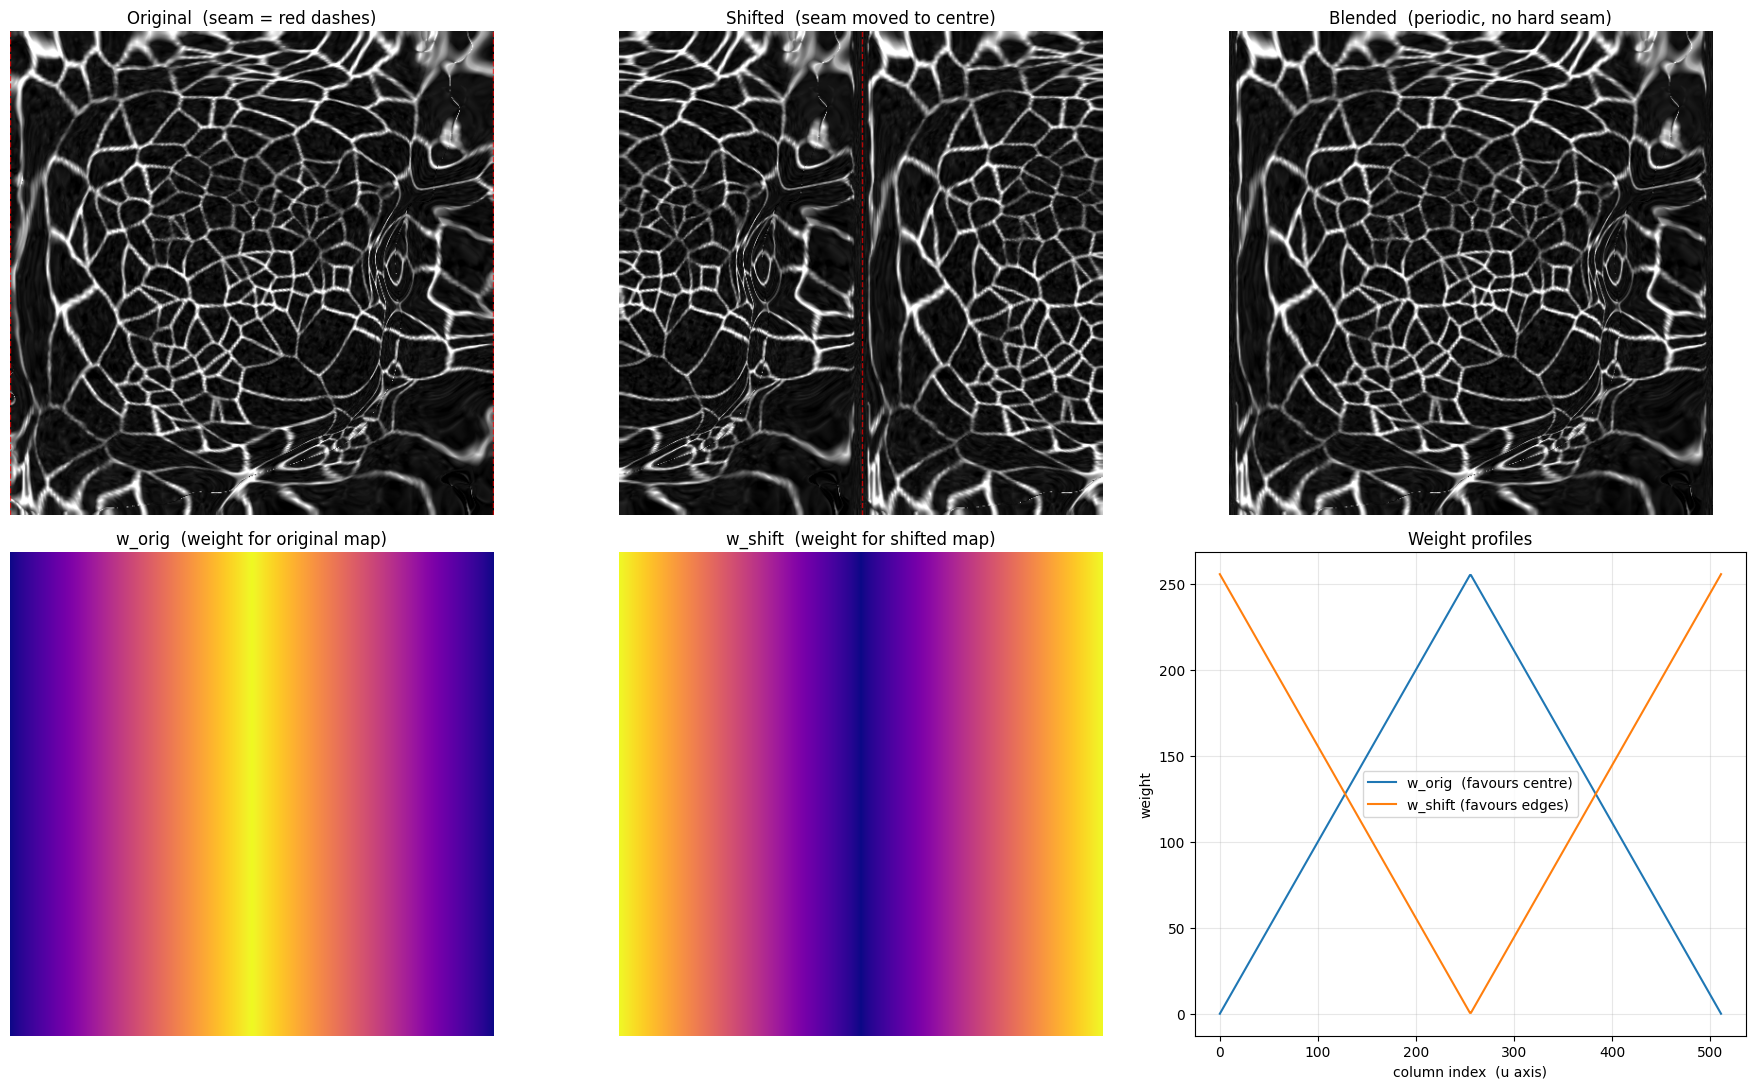

In [20]:
seam_col   = uv_res // 2          # where the shifted seam lands before re-alignment
seam_color = dict(color='red', linewidth=1.0, linestyle='--', alpha=0.7)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── Row 0: projections ────────────────────────────────────────────────────────
kw = dict(cmap='gray', vmin=np.nanpercentile(proj_orig, 1), vmax=np.nanpercentile(proj_orig, 99))

axes[0, 0].imshow(proj_orig, **kw)
axes[0, 0].axvline(0,       **seam_color)   # left seam
axes[0, 0].axvline(uv_res-1, **seam_color)  # right seam (same physical seam)
axes[0, 0].set_title('Original  (seam = red dashes)')

axes[0, 1].imshow(proj_shift, **kw)
axes[0, 1].axvline(seam_col, **seam_color)
axes[0, 1].set_title('Shifted  (seam moved to centre)')

axes[0, 2].imshow(proj_blend, **kw)
axes[0, 2].set_title('Blended  (periodic, no hard seam)')

for ax in axes[0]:
    ax.axis('off')

# ── Row 1: weight maps and weight profile ─────────────────────────────────────
axes[1, 0].imshow(w_o * np.ones((uv_res, uv_res)), cmap='plasma', vmin=0, vmax=w_t.max())
axes[1, 0].set_title('w_orig  (weight for original map)')
axes[1, 0].axis('off')

axes[1, 1].imshow(w_s * np.ones((uv_res, uv_res)), cmap='plasma', vmin=0, vmax=w_t.max())
axes[1, 1].set_title('w_shift  (weight for shifted map)')
axes[1, 1].axis('off')

axes[1, 2].plot(c, w_orig,  label='w_orig  (favours centre)')
axes[1, 2].plot(c, w_shift, label='w_shift (favours edges)')
axes[1, 2].set_xlabel('column index  (u axis)')
axes[1, 2].set_ylabel('weight')
axes[1, 2].set_title('Weight profiles')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Two-chart projection

With `num_charts=2` each chart covers roughly half the surface with its own independent UV space and seam.
`project_to_uv_along_normals` returns one `(L, H, W)` stack per chart.
The hull masks show how each chart's support fills its `[0,1]²` UV domain.

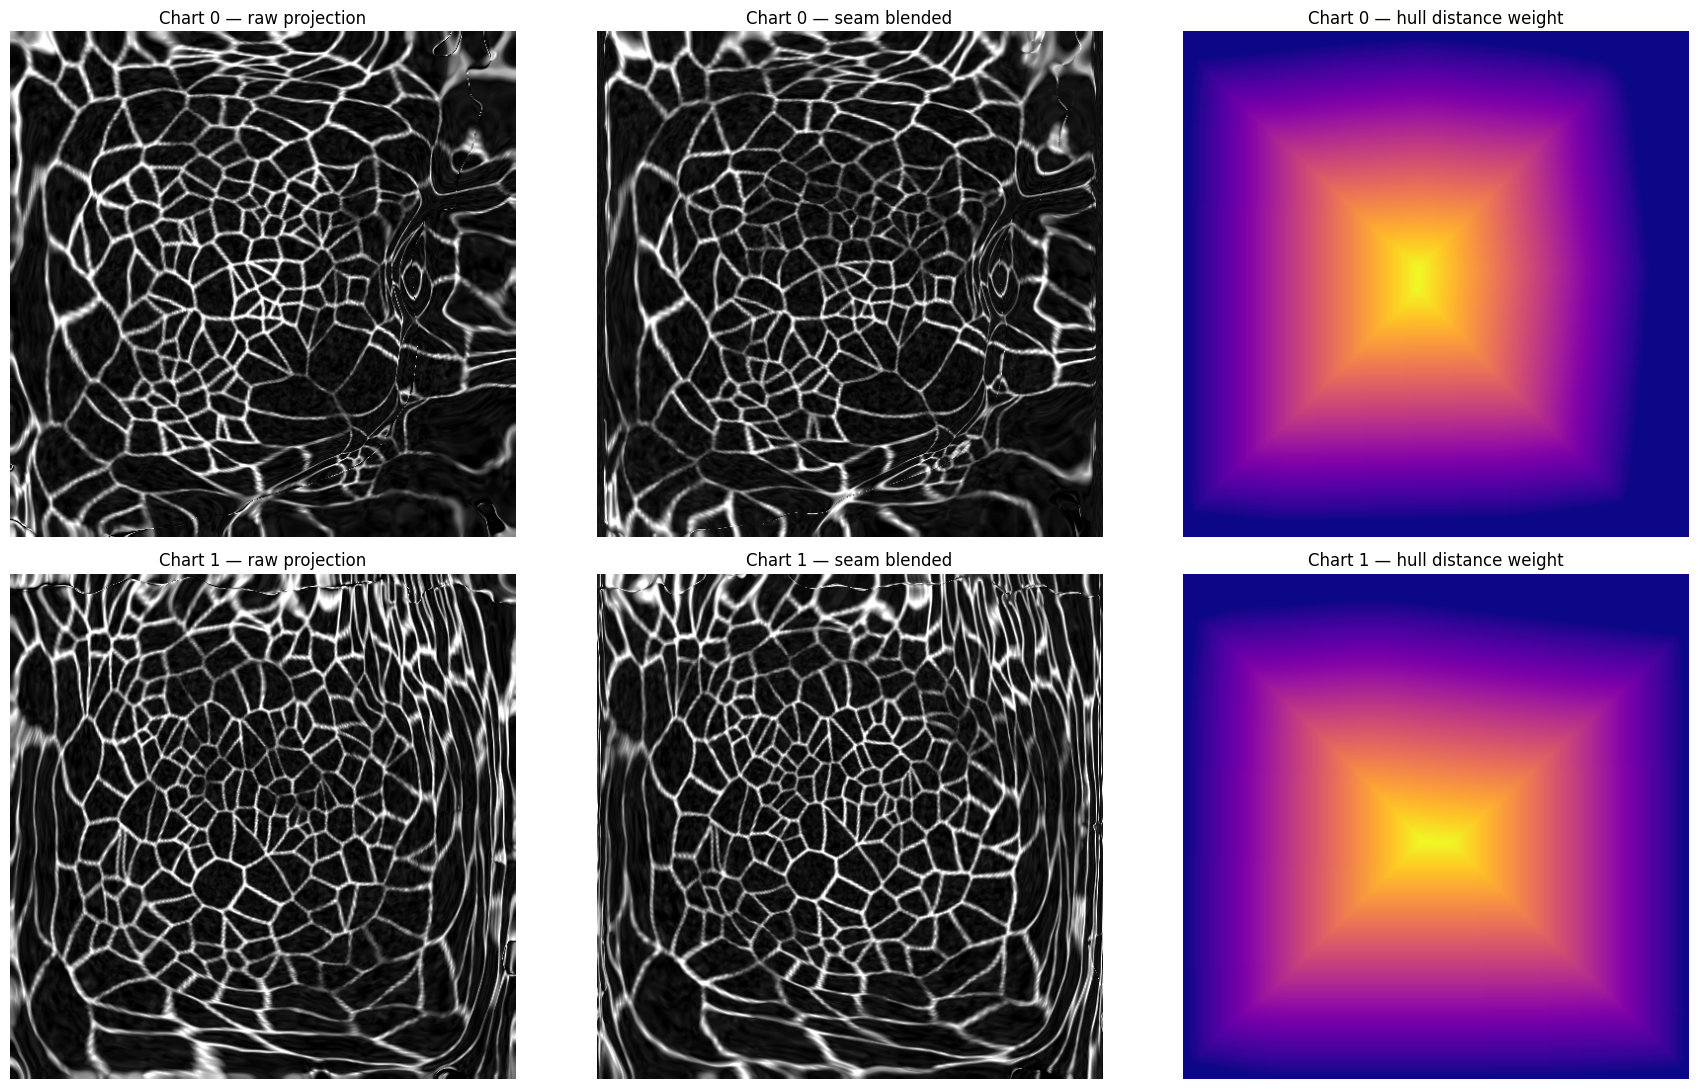

In [21]:
from scipy.ndimage import distance_transform_edt

# Apply seam-shift blend to both charts independently
def seam_blend(model, vol, norm_pts, pts_voxel, topology, device, uv_res, offsets, chart_idx):
    lin = np.linspace(0.0, 1.0, uv_res, dtype=np.float32)
    uu, vv = np.meshgrid(lin, lin, indexing='xy')
    def _proj(uu_query):
        uv_flat = np.stack([uu_query.ravel(), vv.ravel()], axis=1)
        layers, _, _ = project_surface(
            map_model=model, uv_flat=uv_flat, vol=vol,
            norm_points=norm_pts, points=pts_voxel, topology=topology,
            device=device, uv_res=uv_res, normal_offsets=offsets, chart_idx=chart_idx,
        )
        return np.nanmax(np.stack(layers), axis=0)
    p_orig  = _proj(uu)
    p_shift = np.roll(_proj((uu + 0.5) % 1.0), -uv_res // 2, axis=1)
    c = np.arange(uv_res, dtype=float)
    w_o = np.minimum(c, uv_res - 1 - c)[np.newaxis, :]
    w_s = np.abs(c - (uv_res - 1) / 2.0)[np.newaxis, :]
    return (w_o * p_orig + w_s * p_shift) / (w_o + w_s)

blend_0 = seam_blend(param.model, vol, norm_pts, pts_voxel,
                     param.topology, param.device, uv_res, offsets, chart_idx=0)
blend_1 = seam_blend(param.model, vol, norm_pts, pts_voxel,
                     param.topology, param.device, uv_res, offsets, chart_idx=1)

# Distance-transform weights from hull masks (far from boundary = trustworthy)
w_hull_0 = distance_transform_edt(hull_mask_0).astype(np.float32)
w_hull_1 = distance_transform_edt(hull_mask_1).astype(np.float32)

kw = dict(cmap='gray',
          vmin=np.nanpercentile(np.concatenate([blend_0.ravel(), blend_1.ravel()]), 1),
          vmax=np.nanpercentile(np.concatenate([blend_0.ravel(), blend_1.ravel()]), 99))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0, 0].imshow(max_proj_0,  **kw);  axes[0, 0].set_title('Chart 0 — raw projection')
axes[0, 1].imshow(blend_0,     **kw);  axes[0, 1].set_title('Chart 0 — seam blended')
axes[0, 2].imshow(w_hull_0, cmap='plasma'); axes[0, 2].set_title('Chart 0 — hull distance weight')

axes[1, 0].imshow(max_proj_1,  **kw);  axes[1, 0].set_title('Chart 1 — raw projection')
axes[1, 1].imshow(blend_1,     **kw);  axes[1, 1].set_title('Chart 1 — seam blended')
axes[1, 2].imshow(w_hull_1, cmap='plasma'); axes[1, 2].set_title('Chart 1 — hull distance weight')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()